**0. Setup**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap

ImportError: cannot import name 'wrapped_inspect_signature' from 'scipy._lib._util' (/opt/anaconda3/envs/bootcamp/lib/python3.11/site-packages/scipy/_lib/_util.py)

**1. Cargar dataset**

In [2]:
import pandas as pd

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('insurance.csv')

# Mostrar las primeras filas del DataFrame para verificar
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


| Columna  | Significado                  |
| -------- | ---------------------------- |
| age      | Edad                         |
| sex      | Género                       |
| bmi      | Índice de masa corporal      |
| children | Número de hijos dependientes |
| smoker   | Si fuma o no                 |
| region   | Zona geográfica              |
| charges  | Costo médico anual           |


**Chequeos rápidos (EDA mínima)**

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [3]:
# ¿Hay nulos?
df.isna().sum().sort_values(ascending=False)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
# Diferencia grande de gasto entre fumadores / no fumadores suele ser clave
df.groupby("smoker")["charges"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

,count,mean,median
smoker,,,
yes,274,32050.231832,34456.34845
no,1064,8434.268298,7345.40530


**Separar X / y**

In [6]:
X = df.drop(columns="charges")
y = df["charges"]

**Pipeline de preprocesamiento**

In [7]:
numeric_cols = ["age", "bmi", "children"]
categorical_cols = ["sex", "smoker", "region"]


numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("lr", LinearRegression())
])

**Evaluación hold-out (train/test)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.7672642952734356
MAE: 4243.654116653146


In [ ]:
df["charges"].describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


In [ ]:
4244/13270

0.319819140919367

**Interpretación del Error del Modelo**

El modelo obtuvo un: **MAE = 4243**


1. Error relativo respecto del valor máximo

4243 / 13270 ≈ **32%**

Esto significa que, en promedio, el modelo se equivoca en alrededor de un **30% del valor máximo observado** en el dataset.


2. Error relativo respecto del promedio

4243 / 9382 ≈ **45%**

El error promedio equivale aproximadamente a **la mitad del valor típico del dataset**.


Conclusión

Aunque el modelo logra capturar parte de la relación entre las variables (según el R²), el nivel de error aún es considerable.  
Esto indica que:

- La relación no es completamente lineal.
- Podría haber variables importantes no consideradas.
- Podría ser necesario probar modelos más complejos o transformar el target.

El modelo base cumple como punto de partida, pero claramente hay espacio de mejora.

**Validación cruzada**

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
print("R² por fold:", r2_scores)
print("R² promedio:", r2_scores.mean())
print("Desviación estándar:", r2_scores.std())

# MAE
mae_scores = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
print("\nMAE por fold:", mae_scores)
print("MAE promedio:", mae_scores.mean())
print("Desviación estándar:", mae_scores.std())

R² por fold: [0.78359298 0.7380458  0.79558615 0.63243806 0.75131533]
R² promedio: 0.7401956629640443
Desviación estándar: 0.057777855592366645

MAE por fold: [4181.19447375 4242.77953507 4111.04308724 4427.93351222 4054.10990475]
MAE promedio: 4203.412102606214
Desviación estándar: 129.05538534197547


**Analicemos el R²**

Promedio ≈ 0.74
Desviación estándar ≈ 0.025

¿Qué significa esto?

* El modelo es estable.
* La variabilidad entre folds es baja.

El rango es aproximadamente:
* Mínimo ≈ 0.632
* Máximo ≈ 0.795

Eso es un comportamiento muy razonable.

Desviación entre 0.05 es saludable.

Conclusión: el modelo generaliza de forma consistente.

**Analicemos el MAE**

MAE por fold: ~ 4.200 promedio
Desviación estándar ≈ 129

Eso es extremadamente estable.


Si el MAE promedio es 4.200 y la variación es solo 129, eso es alrededor de:

129/ 4200 ≈ 3%

Muy pequeño.

Eso es una señal fuerte de que el modelo no depende críticamente de la partición.

***El modelo explica aproximadamente el 75% de la variabilidad del gasto médico y comete un error promedio estable cercano a 4.200 dólares. La baja desviación entre folds indica que su desempeño es consistente.***

**Grafiquemos**

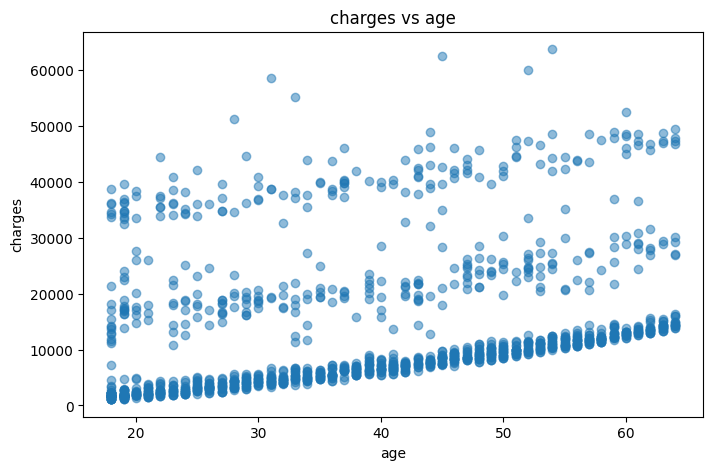

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"], alpha=0.5)
plt.xlabel("age")
plt.ylabel("charges")
plt.title("charges vs age")
plt.show()

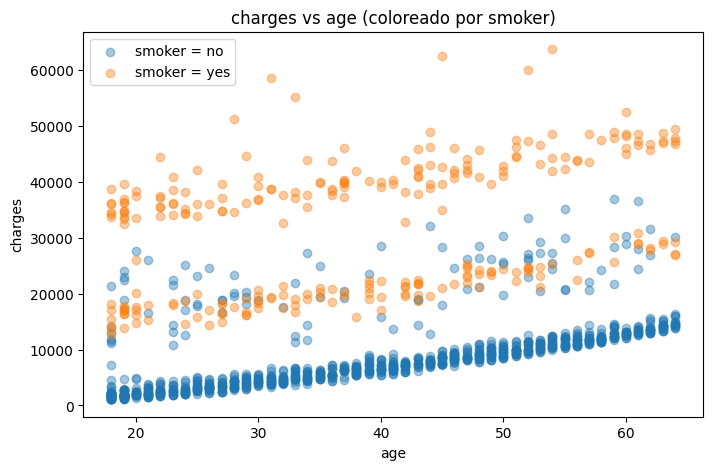

In [ ]:
plt.figure(figsize=(8,5))

mask_yes = df["smoker"] == "yes"
mask_no  = df["smoker"] == "no"

plt.scatter(df.loc[mask_no, "age"],  df.loc[mask_no, "charges"], alpha=0.4, label="smoker = no")
plt.scatter(df.loc[mask_yes,"age"],  df.loc[mask_yes,"charges"], alpha=0.4, label="smoker = yes")

plt.xlabel("age")
plt.ylabel("charges")
plt.title("charges vs age (coloreado por smoker)")
plt.legend()
plt.show()